# Implied Vol Calibration

Author: Sebastien Gurrieri, sebgur@gmail.com

This notebook illustrates the calibration (fit) of the parametric implied vol models supported by the library. At the moment the available models are:
* TsSvi1: parametric term structure for the SVI model, with (approximate) non-arbitrage properties, following [[Gurrieri 2010]](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1779463)
* TsSvi2: parametric term structure for the SVI model, with more parameters than TsSvi2 but without systematic enforcement of no-arbitrage.
* LogMix2: log-normal mixture with 2 components
* LogMix3: log-normal mixture with 3 components

In [ ]:
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import sdevpy as sd
from sdevpy.maths.metrics import rmse
from sdevpy.market import eqvolsurface as vsurf
from sdevpy.market import provider as mdp
from sdevpy.volatility.impliedvol import impliedvol_factory
from sdevpy.volatility.impliedvol.impliedvol_calib import TsIvCalibrator
from sdevpy.volatility.impliedvol import impliedvol
from sdevpy.utilities import timegrids

print("SDevPy version: " + sd.__version__)

SDevPy version: 1.0.5


### Retrieve market data
The SDevPy library has a set of minimalistic market data files containing sample data. Beware that it contains toy data only, to be used strictly for illustration purposes. The data necessary for fitting, which is the expiries, the forwards, the strikes and the volatilities, are all contained in 1 file (per valuation date) and retrieved in an object (dictionary). The user can use the model simply by re-creating that object from their own data.

In [ ]:
name = "ABC"
valdate = dt.datetime(2025, 12, 15)

# Retrieve forward curve
fwd_curve = mdp.get_eq_forward_curves([name], valdate)[0]

# Retrieve option data
file = vsurf.data_file(name, valdate)
option_data = vsurf.eqvolsurfacedata_from_file(file)
mkt_data = {'option_data': option_data, 'forward_curve': fwd_curve}
print(f"Retrieved market data from file {file}")

# Access data in object
expiries = option_data.expiries
fwds = fwd_curve.value(expiries)
mkt_strikes = option_data.get_strikes(fwd_curve=fwd_curve, to_type='absolute')
mkt_vols = option_data.vols

# Quick check of size consistency
print(f"Number of expiries: {len(expiries)}")
print(f"Number of forwards: {len(fwds)}")
print(f"Number of strike sections: {len(mkt_strikes)}")
print(f"Number of vol sections: {len(mkt_vols)}")
for i in range(len(expiries)):
    print(f"Expiry {i+1} number of strikes/vols: {len(mkt_strikes[i])}/{len(mkt_vols[i])}")

option_data.pretty_print()

Retrieved market data from file C:\Code\SDev.Python\datasets\marketdata\eqoptions\ABC\20251215-000000.json
Number of expiries: 6
Number of forwards: 6
Number of strike sections: 6
Number of vol sections: 6
Expiry 1 number of strikes/vols: 5/5
Expiry 2 number of strikes/vols: 5/5
Expiry 3 number of strikes/vols: 5/5
Expiry 4 number of strikes/vols: 5/5
Expiry 5 number of strikes/vols: 5/5
Expiry 6 number of strikes/vols: 5/5
----------------------------------------------------------------------
----------------------------------------------------------------------
Name: ABC
Valuation date: 15-Dec-2025
Snap date: 15-Dec-2025 00:00:00
Strike input type: absolute
Number of expiries: 6
----------------------------------------------------------------------
Expiry 1/6: 20-Jan-2026
Strikes [ 90.2632  94.7008  99.8876 105.3584 110.5382]
Vols [0.3835 0.3258 0.276  0.2935 0.3268]
----------------------------------------------------------------------
Expiry 2/6: 16-Mar-2026
Strikes [ 84.9586  91.6

### Fit Implied Vol Model
In this section we choose and fit an implied vol model, and then display the accuracy of the fit against the market data.

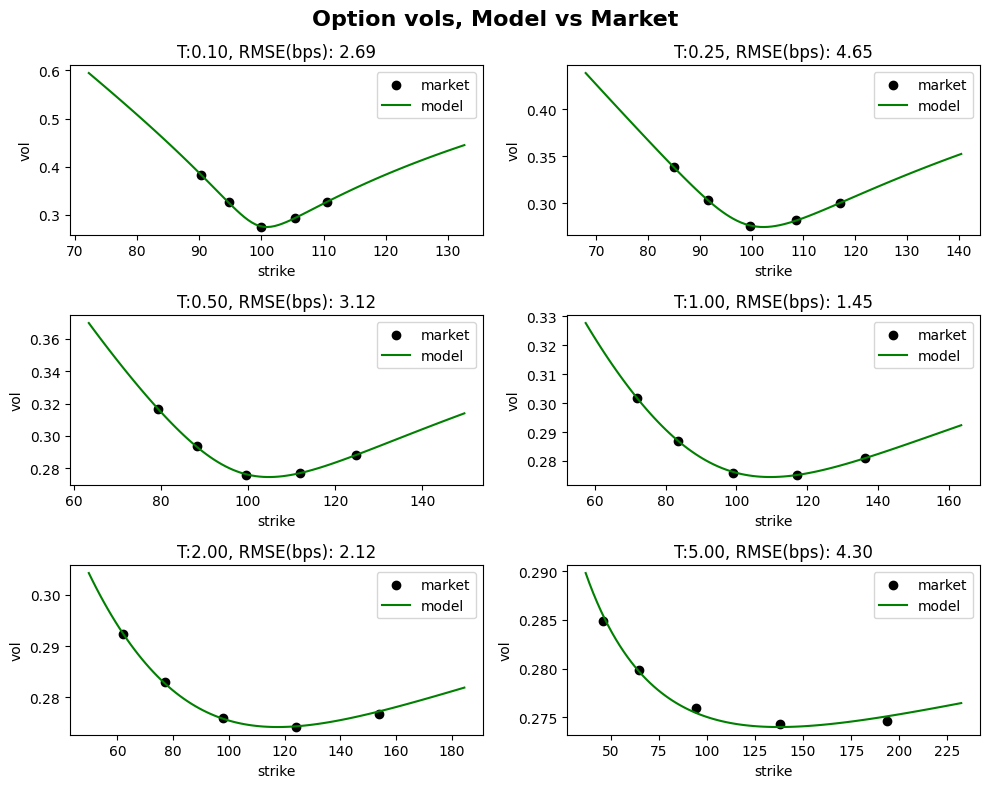

In [ ]:
# Choose model
model_name = 'TsSvi2' # TsSvi1, TsSvi2, LogMix2, LogMix3

# Calibrate
iv_surface = impliedvol_factory.get_new_model(model_name)
calibrator = TsIvCalibrator(iv_surface, {'optimizer': 'SLSQP', 'tol': 1e-6})
calibrator.calibrate(mkt_data)

# Display accuracy of the fit. Estimate model on points and calculate RMSE, plot comparison.
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = timegrids.model_time(valdate, expiries[exp_idx])
        fwd = fwds[exp_idx]
        exp_strikes = mkt_strikes[exp_idx]
        min_k, max_k = exp_strikes[0], exp_strikes[-1]
        m_strikes = np.linspace(0.8 * min_k, 1.2 * max_k, 100)
        m_vols = iv_surface.black_volatility(expiry, m_strikes, fwd)
        ax.scatter(exp_strikes, mkt_vols[exp_idx], label="market", color='black')
        ax.plot(m_strikes, m_vols, label="model", color='green')
        model_vols = iv_surface.black_volatility(expiry, exp_strikes, fwd)
        vol_rmse = rmse(mkt_vols[exp_idx], model_vols)
        ax.set_title(f"T:{expiry:.2f}, RMSE(bps): {10000.0 * vol_rmse:,.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('vol')
        ax.legend()

fig.suptitle('Option vols, Model vs Market', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Dump to file
file = impliedvol.data_file(name, valdate, model_name)
print(f"Dumping model to file: {file}")
iv_surface.dump(file)

Dumping model to file: C:\Code\SDev.Python\datasets\impliedvol\ABC\20251215-000000_TsSvi2.json
